In [3]:
# ==========================================================
# Hotel Booking Cancellation Prediction
# Exploratory Data Analysis (EDA)
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("hotel_bookings.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())



First 5 rows:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Dep


Missing Value Table:
          Missing Values    Percent
children               4   0.003350
country              488   0.408744
agent              16340  13.686238
company           112593  94.306893

Beginning Data Preparation...
Duplicate Rows: 31994

Missing Values After Cleaning:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type           

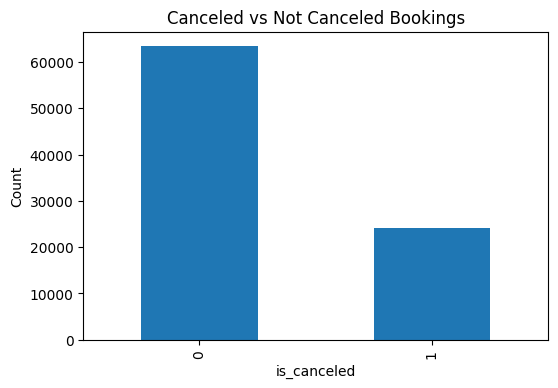

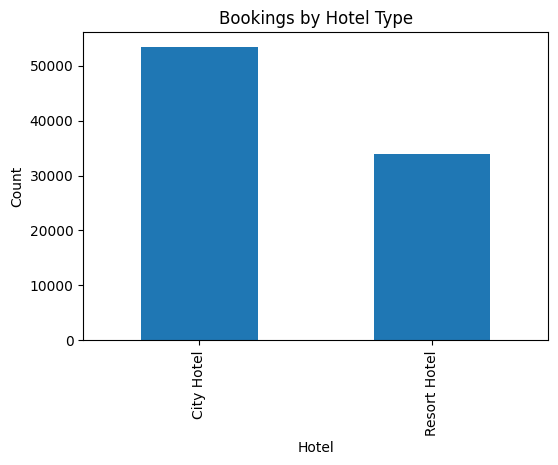

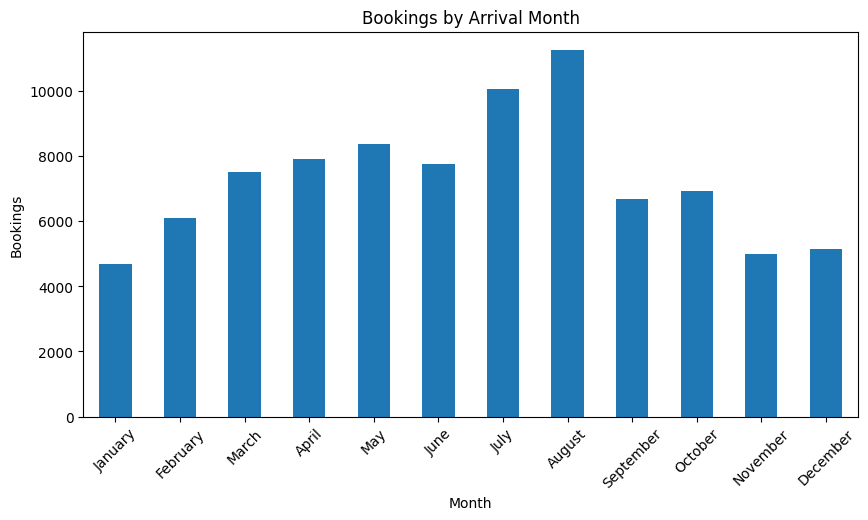

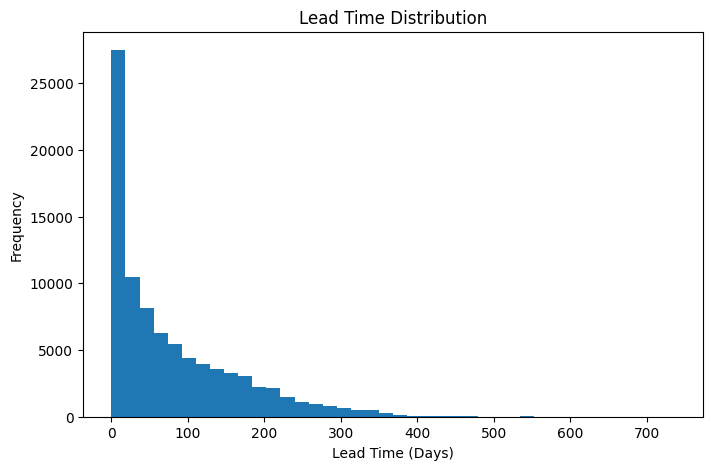

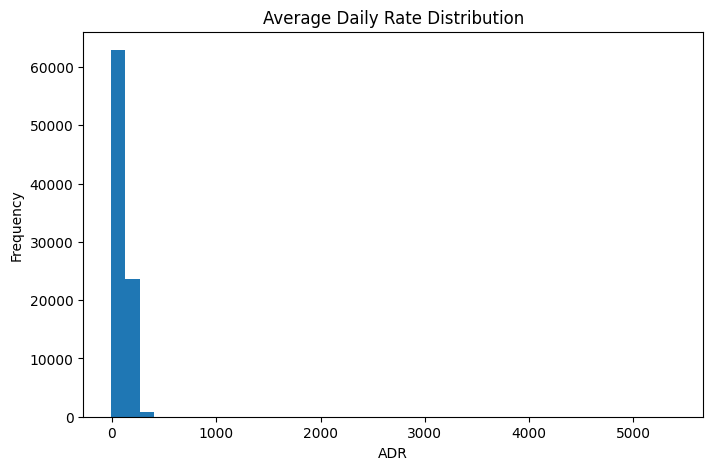

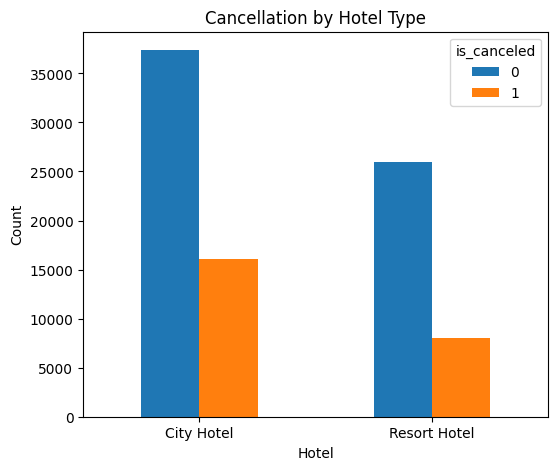

C:\Users\SHAHAX61\AppData\Local\Temp\ipykernel_14388\1003870594.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


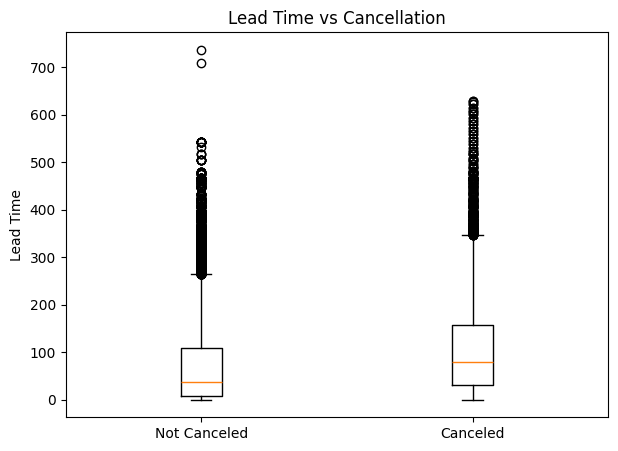

C:\Users\SHAHAX61\AppData\Local\Temp\ipykernel_14388\1003870594.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


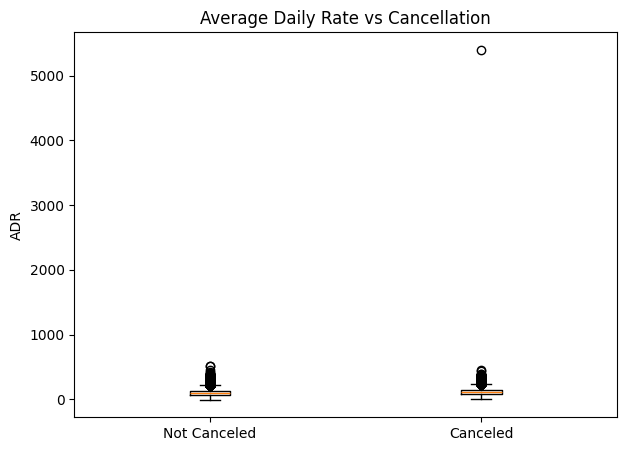

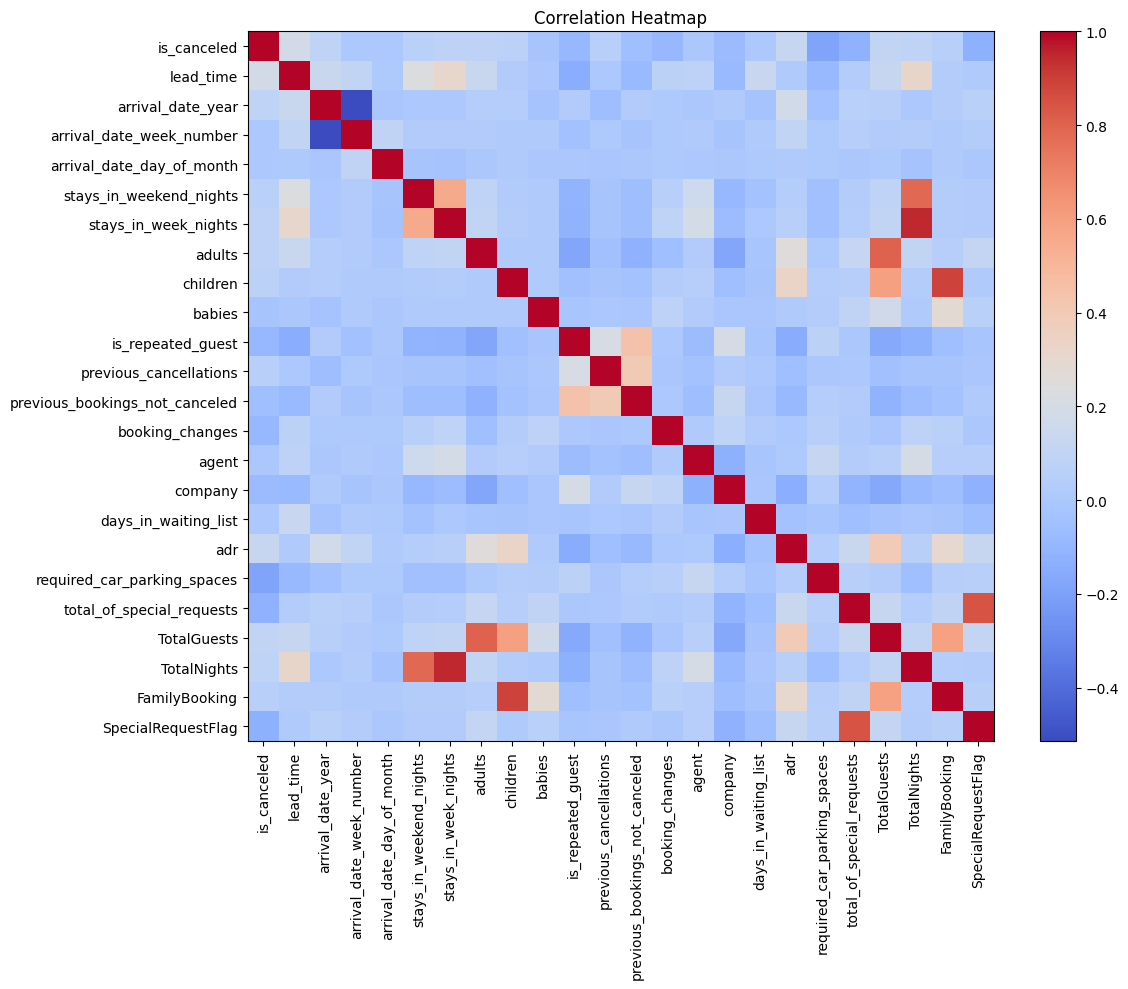

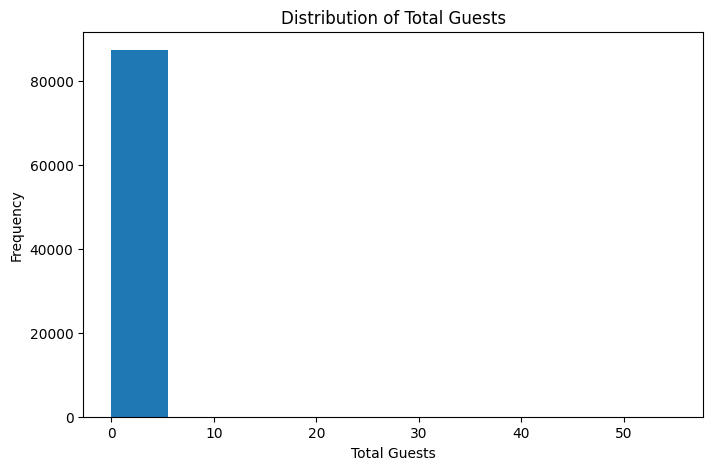

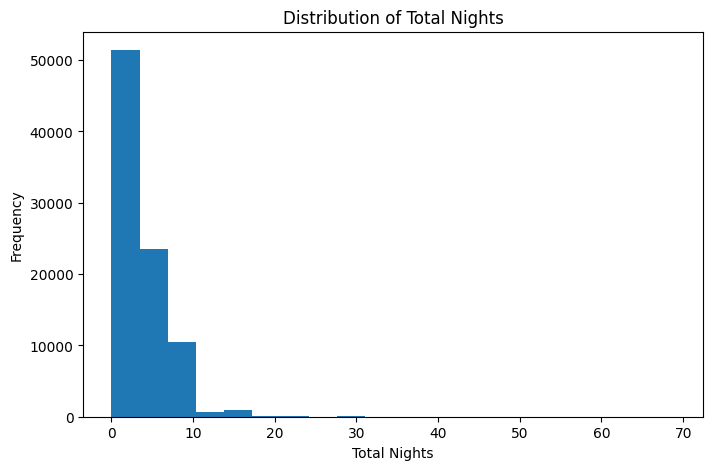

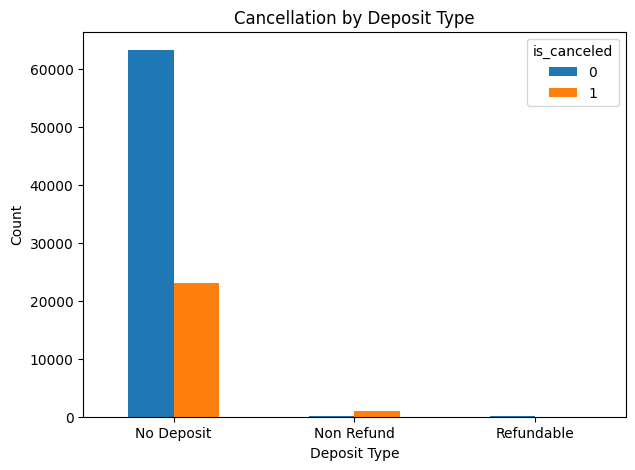

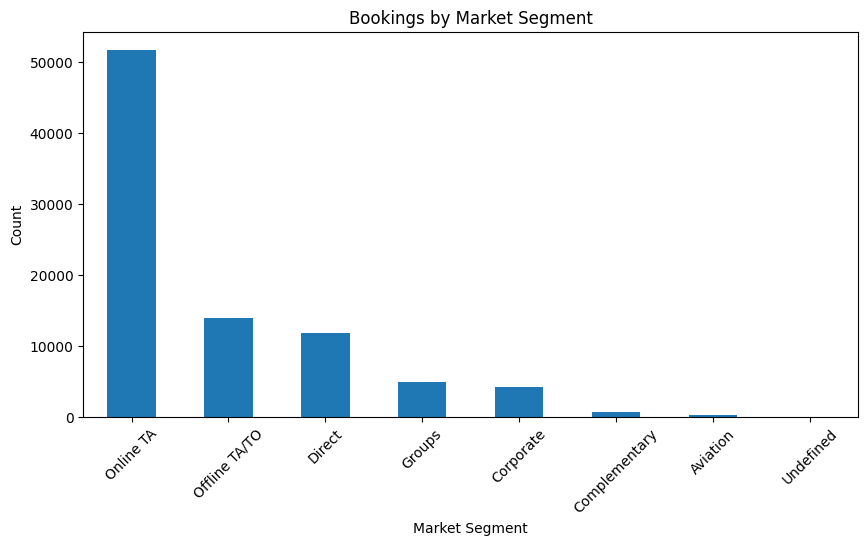


Correlation with is_canceled:
is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
TotalGuests                       0.100257
arrival_date_year                 0.088030
TotalNights                       0.084102
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
FamilyBooking                     0.051649
previous_cancellations            0.051468
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
agent                            -0.000900
babies                           -0.020543
previous_bookings_not_canceled   -0.052154
company                          -0.074758
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
SpecialRequestFlag     

In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent})

print("\nMissing Value Table:")
print(missing_table[missing_table["Missing Values"] > 0])
print("\nBeginning Data Preparation...")
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
df = df.drop_duplicates()
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Feature Engineering
print("\nCreating New Features...")
df["TotalGuests"] = (
    df["adults"] +
    df["children"] +
    df["babies"])
df["TotalNights"] = (
    df["stays_in_week_nights"] +
    df["stays_in_weekend_nights"])
df["FamilyBooking"] = np.where(
    df["children"] + df["babies"] > 0,
    1,
    0)
df["SpecialRequestFlag"] = np.where(
    df["total_of_special_requests"] > 0,
    1,
    0)
df["LeadTimeCategory"] = pd.cut(
    df["lead_time"],
    bins=[-1,30,90,365,1000],
    labels=["Short","Medium","Long","Very Long"])
season_map = {
    "December":"Winter",
    "January":"Winter",
    "February":"Winter",
    "March":"Spring",
    "April":"Spring",
    "May":"Spring",
    "June":"Summer",
    "July":"Summer",
    "August":"Summer",
    "September":"Fall",
    "October":"Fall",
    "November":"Fall"}
df["BookingSeason"] = df["arrival_date_month"].map(season_map)
print("\nNew Features Created:")
print(df[[
    "TotalGuests",
    "TotalNights",
    "FamilyBooking",
    "SpecialRequestFlag",
    "LeadTimeCategory",
    "BookingSeason"
]].head())

#class distribution
plt.figure(figsize=(6,4))
df["is_canceled"].value_counts().plot(kind="bar")
plt.title("Canceled vs Not Canceled Bookings")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

# hotel type
plt.figure(figsize=(6,4))
df["hotel"].value_counts().plot(kind="bar")
plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Count")
plt.show()

# arrival month
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"]
monthly = df["arrival_date_month"].value_counts().reindex(month_order)

plt.figure(figsize=(10,5))
monthly.plot(kind="bar")
plt.title("Bookings by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()

# lead time distribution
plt.figure(figsize=(8,5))
plt.hist(df["lead_time"], bins=40)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

# average daily rate distribution

plt.figure(figsize=(8,5))
plt.hist(df["adr"], bins=40)
plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

# cancellation by hotel type

cancel_by_hotel = pd.crosstab(df["hotel"], df["is_canceled"])
cancel_by_hotel.plot(kind="bar", figsize=(6,5))
plt.title("Cancellation by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# lead time by cancellation
plt.figure(figsize=(7,5))
plt.boxplot([
    df[df["is_canceled"]==0]["lead_time"],
    df[df["is_canceled"]==1]["lead_time"]],
labels=["Not Canceled","Canceled"])
plt.title("Lead Time vs Cancellation")
plt.ylabel("Lead Time")
plt.show()

# ADR by cancellation
plt.figure(figsize=(7,5))
plt.boxplot([
    df[df["is_canceled"]==0]["adr"],
    df[df["is_canceled"]==1]["adr"]],
labels=["Not Canceled","Canceled"])
plt.title("Average Daily Rate vs Cancellation")
plt.ylabel("ADR")
plt.show()

# numerical correlation
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
plt.figure(figsize=(12,10))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
# plt.show()

# total guests distribution
plt.figure(figsize=(8,5))
plt.hist(df["TotalGuests"], bins=10)
plt.title("Distribution of Total Guests")
plt.xlabel("Total Guests")
plt.ylabel("Frequency")
# plt.show()

# total nights distribution
plt.figure(figsize=(8,5))
plt.hist(df["TotalNights"], bins=20)
plt.title("Distribution of Total Nights")
plt.xlabel("Total Nights")
plt.ylabel("Frequency")
# plt.show()

# deposit type vs cancellation
deposit = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"])
deposit.plot(kind="bar", figsize=(7,5))
plt.title("Cancellation by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
# plt.show()

# market segment

plt.figure(figsize=(10,5))
df["market_segment"].value_counts().plot(kind="bar")
plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# top correlations with target
target_corr = corr["is_canceled"].sort_values(ascending=False)
print("\nCorrelation with is_canceled:")
print(target_corr)

# categorical feature counts
categorical = df.select_dtypes(include="object")
for col in categorical.columns:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

model_df = df.copy()
model_df = model_df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"])
y = model_df["is_canceled"]
X = model_df.drop("is_canceled", axis=1)

categorical_features = X.select_dtypes(
    include=["object","category"]).columns

numerical_features = X.select_dtypes(
    exclude=["object","category"]).columns
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print(X_train.shape)
print(X_test.shape)

(69916, 35)
(17480, 35)


In [ ]:
#Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=10000))])
lr_model.fit(X_train, y_train)

#Model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                random_state=42))])
dt_model.fit(X_train, y_train)

#Model 3: Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1))])
#hyperparameter tuning
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None]}
grid_search = GridSearchCV(
    rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest ROC-AUC:")
print(round(grid_search.best_score_, 4))

#Model 4: Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42))])
gb_model.fit(X_train, y_train);

C:\Users\SHAHAX61\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Parameters:
{'classifier__max_depth': None, 'classifier__n_estimators': 200}

Best ROC-AUC:
0.8994


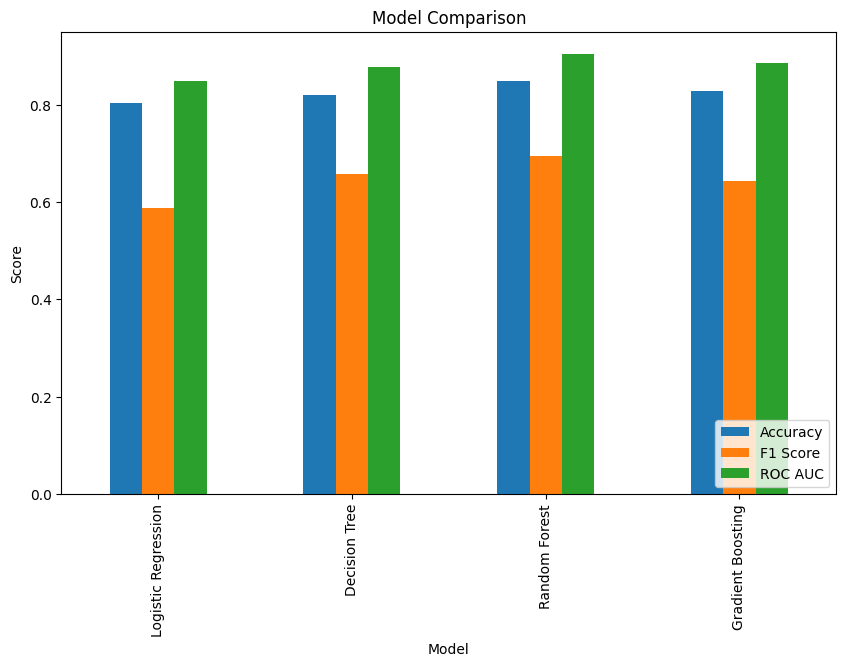

In [7]:
#Model Evaluation and Visualization
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score)
def evaluate_model(model, X_test, y_test, name):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:,1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(
            y_test,
            probabilities)}
results = []
results.append(
    evaluate_model(
        lr_model,
        X_test,
        y_test,
        "Logistic Regression"))
results.append(
    evaluate_model(
        dt_model,
        X_test,
        y_test,
        "Decision Tree"))
results.append(
    evaluate_model(
        best_rf_model,
        X_test,
        y_test,
        "Random Forest"))
results.append(
    evaluate_model(
        gb_model,
        X_test,
        y_test,
        "Gradient Boosting"))
results_df = pd.DataFrame(results)
results_df

results_df.plot(
    x="Model",
    y=["Accuracy","F1 Score","ROC AUC"],
    kind="bar",
    figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.show()

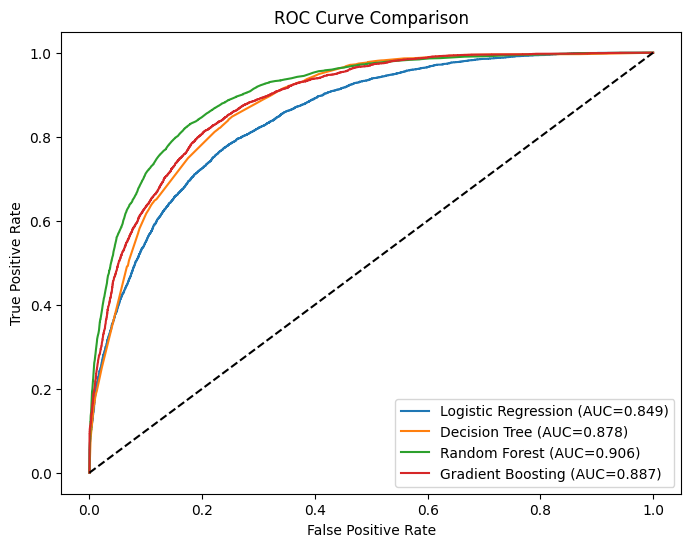

In [8]:
#ROC Curve 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": best_rf_model,
    "Gradient Boosting": gb_model}
plt.figure(figsize=(8,6))
for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(
        y_test,
        probs)
    auc = roc_auc_score(
        y_test,
        probs)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})")
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [9]:
#5-Fold Cross Validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    best_rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc")
print("Cross Validation Scores:")
print(cv_scores)
print("Average ROC-AUC:")
print(cv_scores.mean())

Cross Validation Scores:
[0.65360321 0.63374694 0.3457706  0.33474273 0.61569126]
Average ROC-AUC:
0.5167109471915944


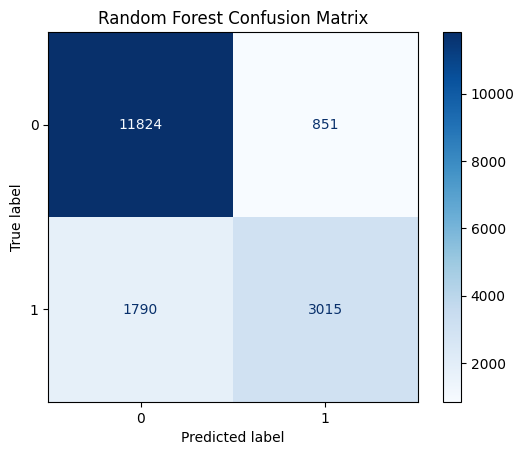

CV ROC-AUC Scores
[0.6536026  0.63374679 0.34577201 0.33474258 0.61569295]
Average:
0.5167113872771961


In [10]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
best_model = best_rf_model
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

#Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    best_rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc")
print("CV ROC-AUC Scores")
print(scores)
print("Average:")
print(scores.mean())

In [11]:
rf = best_rf_model.named_steps["classifier"]
feature_names = best_rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False)
print(importance_df.head(15))

                              Feature  Importance
0                      num__lead_time    0.092581
16                           num__adr    0.071175
3      num__arrival_date_day_of_month    0.055998
2       num__arrival_date_week_number    0.047923
13                         num__agent    0.043317
172                  cat__country_PRT    0.042884
20                   num__TotalNights    0.037713
18     num__total_of_special_requests    0.034882
5           num__stays_in_week_nights    0.034876
219     cat__market_segment_Online TA    0.025677
17   num__required_car_parking_spaces    0.024142
4        num__stays_in_weekend_nights    0.023885
1              num__arrival_date_year    0.023030
22            num__SpecialRequestFlag    0.020658
256       cat__LeadTimeCategory_Short    0.018781
